In [1]:
import pandas as pd 
import numpy as np
import random
import os 
import json
import torch
import pickle
import matplotlib.pyplot as plt
from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score , recall_score , confusion_matrix, f1_score, classification_report
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from attrdict import AttrDict
from sklearn.preprocessing import minmax_scale
from transformers import AdamW, get_linear_schedule_with_warmup
from transformers import BertConfig, BertTokenizer, BertModel
from torchmetrics import R2Score

C:\Users\lamda\.conda\envs\aaai\lib\site-packages\torchaudio\backend\utils.py:66: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


In [2]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
model_path = os.path.join(default_path, '../models')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
config_file = "bert-base.json"

In [3]:
criteria = 4

In [4]:
X_train = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_test.csv'))

In [5]:
reddit = pd.read_csv(os.path.join(data_path, 'reddit_dsm_ngram.csv'))
reddit.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False


In [6]:
untagged_data = reddit[reddit.label==2]
print(f'len data: {len(untagged_data)}')
untagged_data.head(3)

len data: 7666


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
107425,t3_cg8atp,depression,MavYaBoy,Ive gained weight because of my stress eating ...,comment,1.563768e+09,t3_cg8atp,eufbl8s,24,2,True,False,False
107426,t3_3lhc9y,depression,m0s3s4,To be quite honest my eating habits are not t...,comment,1.442616e+09,t1_cv6d6ru,cv6dysv,23,2,True,False,False
107427,t3_5frhj3,depression,catsRawesome123,I am not fat and it is not about weight or app...,comment,1.480537e+09,t1_damhlxr,damiwqj,13,2,True,False,False


In [7]:
untagged_data.reset_index(inplace=True, drop=True)

In [8]:
untagged_data[untagged_data.text==' ']

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c


In [9]:
tokenizer = BertTokenizer.from_pretrained(os.path.join(base_model, 'bert-base'), model_max_length=128)
config = BertConfig.from_pretrained(os.path.join(base_model, 'bert-base', 'bert_config.json'))
model = BertModel.from_pretrained(os.path.join(base_model, 'bert-base'), config=config)

In [10]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [11]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [12]:
training_config.model_path = model_path 
training_config.log_path = log_path

In [13]:
training_config

AttrDict({'default_path': '../', 'data_path': 'data', 'log_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../log', 'model_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../models', 'config_path': 'config', 'seed': 42, 'train_batch_size': 8, 'device': device(type='cuda'), 'eval_batch_size': 8, 'num_epochs': 5, 'gradient_accumulation_steps': 1, 'warmup_proportion': 0, 'adam_epsilon': 1e-08, 'learning_rate': 5e-05, 'do_lower_case': False, 'no_cuda': False, 'max_steps': -1, 'logging_steps': 100})

In [14]:
training_config.learning_rate

5e-05

In [15]:
training_config.pad = 'max_length'
training_config.num_epochs = 10

In [16]:
class BertDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file
    
    def __len__(self):
        return len(self.data.label)
    
    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)
    
    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [17]:
class BertProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer 
        self.max_len = config.max_position_embeddings
        self.pad = training_config.pad
        self.batch_size = training_config.train_batch_size
        self.truncation = truncation
    
    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text, 
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )
        
        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1] 
            except:
                # print('input label 오류')
                inputs['label'] = 0 
            features.append(inputs)
        
        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        dataset = TensorDataset(all_input_ids, all_attention_mask, all_token_type_ids, all_labels)
        return dataset
    
    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)
        
    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [18]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [19]:
class BertRegressor(nn.Module):
    def __init__(self, config, model):
        super(BertRegressor, self).__init__()
        self.model = model
        self.linear = nn.Linear(config.hidden_size, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 1)
    
    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        logits = outputs.last_hidden_state[:, 0, :]
        # print(f'logits: {len(logits)}, {len(logits[0])}')
        x = self.linear(logits)
        x = self.relu(x)
        score = self.out(x)
        # print(f'score: {score}')
        return score 

In [20]:
class BertTrainer():
    def __init__(self, config, training_config, model, train_dataloader, eval_dataloader):
        self.config = config
        self.training_config = training_config
        self.model = model
        self.train_dataloader = train_dataloader
        self.eval_dataloader = eval_dataloader
        
    def set_seed(self):
        random.seed(self.training_config.seed)
        np.random.seed(self.training_config.seed)
        torch.manual_seed(self.training_config.seed)
        if not self.training_config.no_cuda and torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.training_config.seed)
    
    def train(self):
        global_step = 0; nb_eval_steps = 0
        train_rmse = []; eval_rmse = []
        t_total = len(self.train_dataloader) // self.training_config.gradient_accumulation_steps * self.training_config.num_epochs

        optimizer = AdamW(self.model.parameters(), lr=self.training_config.learning_rate, eps=self.training_config.adam_epsilon)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(t_total * self.training_config.warmup_proportion), \
                                                    num_training_steps=t_total)
        
        criterion = RMSELoss
        # criterion = nn.MSELoss()
        best_loss = 9999 
        
        self.model.zero_grad()
        for epoch in range(int(self.training_config.num_epochs)):
            train_loss = 0.0; eval_loss = 0.0 
            
            for step, batch in enumerate(self.train_dataloader):
                self.model.train()
                batch = tuple(t.to(self.training_config.device) for t in batch)
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(f'output: {type(outputs)}, {outputs.squeeze}')
                label = batch[3]
                # print(f'label: {label}')
                # print(f'output: {outputs}, {outputs.squeeze()}')
                loss = criterion(outputs.squeeze(), batch[3].type_as(outputs))
                loss.backward()
                
                train_loss += loss.item()
                # torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.training_config.max_grad_norm)
                optimizer.step()
                scheduler.step()
                
                self.model.zero_grad()
            
            print(f'epoch: {epoch + 1} done, train_loss: {train_loss / len(self.train_dataloader)}')
            train_rmse.append(train_loss / len(self.train_dataloader))

            for step2, batch2 in enumerate(self.eval_dataloader):
                self.model.eval()
                batch2 = tuple(t.to(self.training_config.device) for t in batch2)

                with torch.no_grad():
                    inputs = {
                        "input_ids": batch2[0],
                        "attention_mask": batch2[1],
                        "token_type_ids": batch2[2],
                    }
                    label2 = batch2[3]
                    outputs = self.model(**inputs)
                    print(f'eval output: {outputs.squeeze()}, eval label: {label2.type_as(outputs)}')
                    tmp_eval_loss = criterion(outputs.squeeze(), label2.type_as(outputs))
                    eval_loss += tmp_eval_loss.mean().item()
                    
                nb_eval_steps += 1

            eval_loss = eval_loss / nb_eval_steps
            eval_rmse.append(eval_loss)

        self.save_log(train_rmse, eval_rmse, epoch+1)
        self.save_model(os.path.join(self.training_config.default_path, self.training_config.model_path, f'bert_bws_a{criteria}_e10.pt'))
        return train_rmse, eval_rmse

    def save_log(self, train_mse, eval_mse, epoch):
        with open(os.path.join(self.training_config.default_path, self.training_config.log_path, f'train_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(train_mse, f, pickle.HIGHEST_PROTOCOL)  
        
        with open(os.path.join(self.training_config.default_path, self.training_config.log_path, f'eval_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(eval_mse, f, pickle.HIGHEST_PROTOCOL)  
    
    def save_model(self, model_name):
        torch.save(self.model.state_dict(), model_name)

In [21]:
train_file = BertDataset(X_train)
val_file = BertDataset(X_dev)
test_file = BertDataset(X_test)

In [22]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [23]:
bert_processor = BertProcessor(config, training_config, tokenizer)

In [24]:
train_dataset = bert_processor.convert_data(train_file)
val_dataset = bert_processor.convert_data(val_file)
test_dataset = bert_processor.convert_data(test_file)

In [25]:
train_sampler = bert_processor.shuffle_data(train_dataset, 'train')
val_sampler = bert_processor.shuffle_data(val_dataset, 'eval')
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')

In [26]:
train_dataloader = bert_processor.load_data(train_dataset, train_sampler)
val_dataloader = bert_processor.load_data(val_dataset, val_sampler)
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [27]:
len(train_dataloader), len(val_dataloader)

(144, 16)

In [28]:
model_reg = BertRegressor(config, model).to(training_config.device)  

In [29]:
bert_trainer = BertTrainer(config, training_config, model_reg, train_dataloader, val_dataloader)

In [30]:
train_mse, eval_mse = bert_trainer.train()

C:\Users\lamda\.conda\envs\aaai\lib\site-packages\transformers\optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


epoch: 1 done, train_loss: 2.511446954061588
eval output: tensor([2.5174, 4.2085, 5.5669, 6.2089, 4.4622, 4.1691, 2.3889, 6.2077],
       device='cuda:0'), eval label: tensor([3., 5., 3., 7., 1., 3., 3., 7.], device='cuda:0')
eval output: tensor([2.1854, 4.8704, 3.5376, 4.3373, 3.0319, 3.2590, 5.2557, 6.0498],
       device='cuda:0'), eval label: tensor([2., 5., 5., 7., 2., 3., 5., 5.], device='cuda:0')
eval output: tensor([5.6181, 5.1685, 3.9904, 5.2823, 2.0250, 2.9394, 5.6979, 5.7654],
       device='cuda:0'), eval label: tensor([3., 7., 3., 5., 3., 2., 8., 0.], device='cuda:0')
eval output: tensor([6.2714, 1.6628, 6.3707, 4.8542, 6.2303, 4.1551, 5.0306, 5.6004],
       device='cuda:0'), eval label: tensor([8., 5., 7., 2., 8., 3., 0., 7.], device='cuda:0')
eval output: tensor([5.0045, 3.6936, 4.8744, 4.7776, 2.2115, 4.6955, 3.3213, 6.0945],
       device='cuda:0'), eval label: tensor([1., 3., 8., 2., 1., 5., 6., 5.], device='cuda:0')
eval output: tensor([5.1295, 6.2515, 5.9301, 4.221

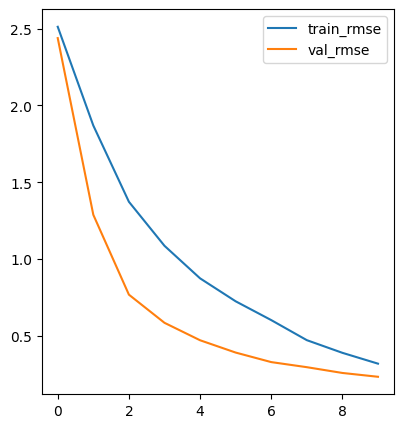

In [31]:
num_epochs = list(range(len(train_mse)))
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(list(range(len(train_mse))), train_mse, label='train_rmse')
plt.plot(list(range(len(eval_mse))), eval_mse, label='val_rmse')

plt.legend()
plt.show()

In [32]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [33]:
y_pred, y_true = bert_tester.get_label(untagged_dataloader, 0)

NameError: name 'bert_tester' is not defined

In [88]:
criterion = RMSELoss

In [89]:
loss = criterion(torch.Tensor(y_pred), torch.Tensor((y_true)))
loss

NameError: name 'y_pred' is not defined

In [128]:
r2score = R2Score()
r2score(torch.Tensor(y_pred), torch.Tensor(y_true))

tensor(0.5099)

In [137]:
y_pred, y_true = bert_tester.get_label(untagged_dataloader, 0)

In [138]:
len(y_pred), len(y_true)

(7666, 7666)

In [143]:
untagged_data.to_csv(os.path.join(data_path, 'untagged_a3_pseudo.csv'), index=False)

In [144]:
a1_train, a1_test = train_test_split(untagged_data, test_size=0.2, random_state=42) #, stratify=a1.label)
a1_train, a1_dev = train_test_split(a1_train, test_size=0.1, random_state=42) #, stratify=a1_train.label)

In [145]:
a1_train.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_train.csv'), index=False)
a1_dev.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_val.csv'), index=False)
a1_test.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_test.csv'), index=False)